# Convert Astra to Bmad

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
JSON_OUT = "sc_inj_bmad_settings.json"
GUNB_SETTINGS_OUTFILE = "$LCLS_LATTICE/bmad/master/gunb/gunb_settings.bmad"
L0B_SETTINGS_OUTFILE  = "$LCLS_LATTICE/bmad/master/l0b/l0b_settings.bmad"

In [3]:
from astra import Astra
from distgen import Generator

from astra.interfaces.bmad import bmad_cavity, bmad_solenoid

import json
import os

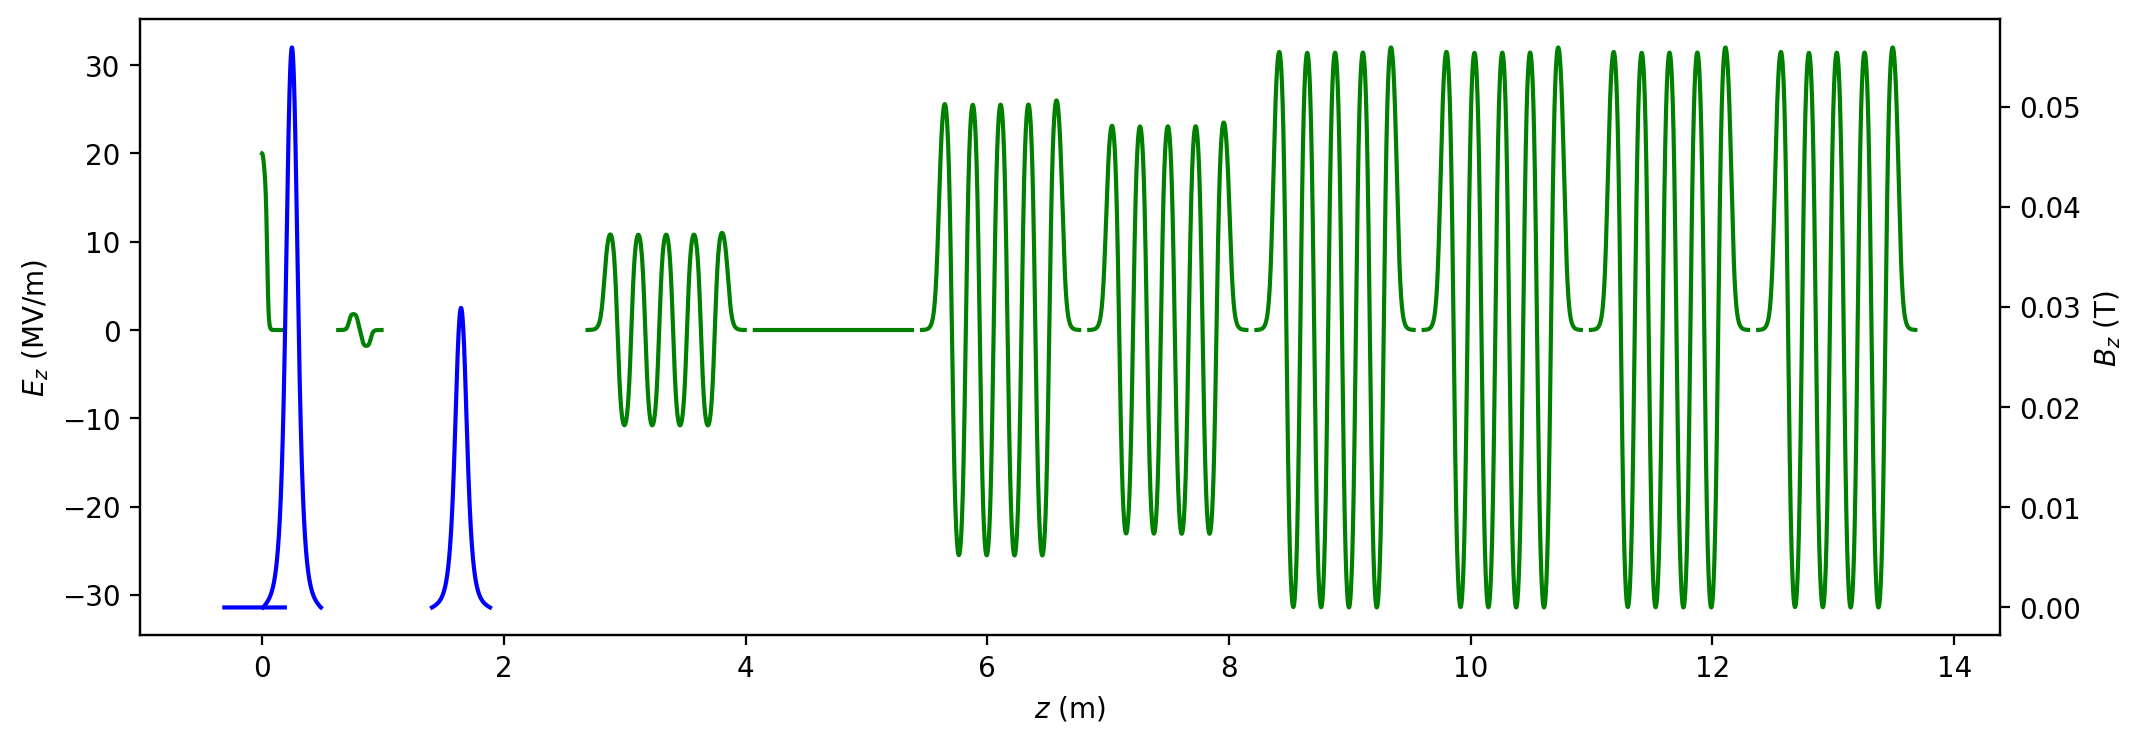

In [4]:
A = Astra('$LCLS_LATTICE/astra/models/sc_inj/v1/astra.in')
A.load_fieldmaps(search_paths=[os.path.expandvars('$LCLS_LATTICE/astra/fieldmaps')])
A.plot()

In [5]:
A.input['solenoid']

{'file_bfield(1)': 'realbucking.dat',
 'file_bfield(2)': 'newSOL.dat',
 'file_bfield(3)': 'newSOL.dat',
 'lbfield': True,
 'maxb(1)': 0,
 'maxb(2)': 0.0559,
 'maxb(3)': 0.0299,
 's_higher_order(1)': True,
 's_higher_order(2)': True,
 's_higher_order(3)': True,
 's_pos(1)': -0.062,
 's_pos(2)': 0.24653,
 's_pos(3)': 1.64581,
 's_smooth(1)': 10,
 's_smooth(2)': 10,
 's_smooth(3)': 10,
 's_xoff(1)': 0,
 's_xoff(2)': 0,
 's_xoff(3)': 0,
 's_yoff(1)': 0,
 's_yoff(2)': 0,
 's_yoff(3)': 0}

In [6]:
from astra.fieldmaps import find_fieldmap_ixlist
from pmd_beamphysics.fields.analysis import accelerating_voltage_and_phase

# Gun

In [7]:
gun = bmad_cavity(A, 1, name='RFGUNB', keyword='apex_gun', superimpose=False)

print(gun['line'])

RFGUNB: apex_gun,
      rf_frequency = 187000000.0,
      phi0 = 0.02361111111111111,
      autoscale_amplitude = False,
      field_autoscale = 20000000.0


In [8]:
gun

{'attrs': {'rf_frequency': 187000000.0,
  'phi0': 0.02361111111111111,
  'autoscale_amplitude': False,
  'field_autoscale': 20000000.0},
 'ele_key': 'apex_gun',
 'ele_name': 'RFGUNB',
 'line': 'RFGUNB: apex_gun,\n      rf_frequency = 187000000.0,\n      phi0 = 0.02361111111111111,\n      autoscale_amplitude = False,\n      field_autoscale = 20000000.0'}

# Solenoids

In [9]:
A.input['solenoid']['s_pos(2)']

0.24653

In [10]:
sols = [
#    bmad_solenoid(A, 1, name='SOL1BKB', keyword='lcls2_bucking_solenoid', ele_origin='beginning', ref_offset = -0.1),
    bmad_solenoid(A, 2, name='SOL1B', keyword='lcls2_solenoid', ele_origin='beginning', ref_offset = 0),
    bmad_solenoid(A, 3, name='SOL2B', keyword='lcls2_solenoid', ele_origin='beginning', ref_offset = 0)
]
for ele in sols:
    print(ele['line'])

SOL1B: lcls2_solenoid,
  ! B_max = 0.0559 T
! \int B dL = B_max * 0.12896517423475376 m
! \int B^2 dL = B_max^2 * 0.08623994625099243 m
! Hard edge L = 0.19285745050205194 m
! Hard edge B = 0.03738073494674779 T,
      bs_field = 0.0559,
      superimpose = True,
      ele_origin = beginning,
      offset = 0.24653
SOL2B: lcls2_solenoid,
  ! B_max = 0.0299 T
! \int B dL = B_max * 0.12896517423475376 m
! \int B^2 dL = B_max^2 * 0.08623994625099243 m
! Hard edge L = 0.19285745050205194 m
! Hard edge B = 0.019994346599423236 T,
      bs_field = 0.0299,
      superimpose = True,
      ele_origin = beginning,
      offset = 1.64581


# Cavities

In [11]:
cav_names = [f'CAVL01{i}' for i in range(1,9)]
cav_names

['CAVL011',
 'CAVL012',
 'CAVL013',
 'CAVL014',
 'CAVL015',
 'CAVL016',
 'CAVL017',
 'CAVL018']

In [12]:
buncher = bmad_cavity(A, 2, name='BUN1B', keyword='apex_buncher_1300MHz')

cavs = [buncher] + [bmad_cavity(A, ix, name=name, keyword='cavity9_1300MHz') for ix, name in zip(range(3,11), cav_names)]

for ele in cavs:
    print(ele['line'])

BUN1B: apex_buncher_1300MHz,
      rf_frequency = 1300000000.0,
      phi0 = -0.24583333333333332,
      autoscale_amplitude = False,
      field_autoscale = 1800000.0,
      offset = 0.809116,
      superimpose = True,
      ele_origin = center
CAVL011: cavity9_1300MHz,
      rf_frequency = 1300000000.0,
      phi0 = 0.022222222222222223,
      autoscale_amplitude = False,
      field_autoscale = 11000000.0,
      offset = 3.3428,
      superimpose = True,
      ele_origin = center
CAVL012: cavity9_1300MHz,
      rf_frequency = 1300000000.0,
      phi0 = -0.025,
      voltage = 0,
      offset = 4.7264,
      superimpose = True,
      ele_origin = center
CAVL013: cavity9_1300MHz,
      rf_frequency = 1300000000.0,
      phi0 = -0.05555555555555555,
      autoscale_amplitude = False,
      field_autoscale = 26000000.0,
      offset = 6.11,
      superimpose = True,
      ele_origin = center
CAVL014: cavity9_1300MHz,
      rf_frequency = 1300000000.0,
      phi0 = 0.07222222222222222,
 

# Dump to JSON

In [13]:
ALLDAT = [gun] + sols + cavs
json.dump(ALLDAT, open(JSON_OUT, "w"))

In [14]:
# Check reload
json.load(open(JSON_OUT));

In [15]:
# Write Bmad settings

In [16]:
def write_settings(fname, eles):
    fname = os.path.expandvars(fname)
    lines = []
    for d in eles:
        name = d['ele_name']
        lines.append(f'! {name}')
        for k, v in d['attrs'].items():
            if k in ['voltage', 'autoscale_amplitude', 'field_autoscale', 'phi0', 'bs_field']:
            
                lines.append(f"{name}[{k}] = {v}")
        lines.append('')
    with open(fname, 'w') as f:
        f.write('\n'.join(lines))

write_settings(GUNB_SETTINGS_OUTFILE, [gun] + cavs[0:2] + sols)
write_settings(L0B_SETTINGS_OUTFILE, cavs[1:])

# Test Astra 

In [17]:
from pmd_beamphysics import single_particle
from pmd_beamphysics.particles import join_particle_groups

In [18]:
dx = 1e-6
dy = 1e-6
dt = 1e-12

P0 = join_particle_groups(*[single_particle(),
 single_particle(x=-dx),
 single_particle(y=-dy),
 single_particle(t=-dt),
 single_particle(x=dx),
 single_particle(y=dy),
 single_particle(t=dt)])

P0FILE = '$LCLS_LATTICE/bmad/models/sc_inj/cathode_probe_particles.h5'
P0.write(P0FILE)

P0

<ParticleGroup with 7 particles at 0x15cb06d60>

In [19]:
#ZSTOP = 0.2
ZSTOP = 18.174867


A = Astra('$LCLS_LATTICE/astra/models/sc_inj/v1/astra.in')
A.load_fieldmaps(search_paths=[os.path.expandvars('$LCLS_LATTICE/astra/fieldmaps')])
A['charge:lspch'] = False
A.initial_particles = P0
A.verbose=False
A.timeout=1000

# Test
#for i in range(1, 11):
#    A.input['cavity'][f'c_smooth({i})'] = 0
#for i in range(1, 4):
#    A.input['solenoid'][f's_smooth({i})'] = 0    
    
#A.input['cavity']['phi(1)'] = 0 # TEST

#A.input['newrun']['h_max'] = 0.0075 /2
# A.input['newrun']['max_step'] = 1_000_000 
A.input['output']['zphase'] = 150
A.input['output']['zstop'] = ZSTOP

A.run()

set(map(len, A.particles)), len( A.particles)

A.input['newrun']['h_max']

0.0075

[]

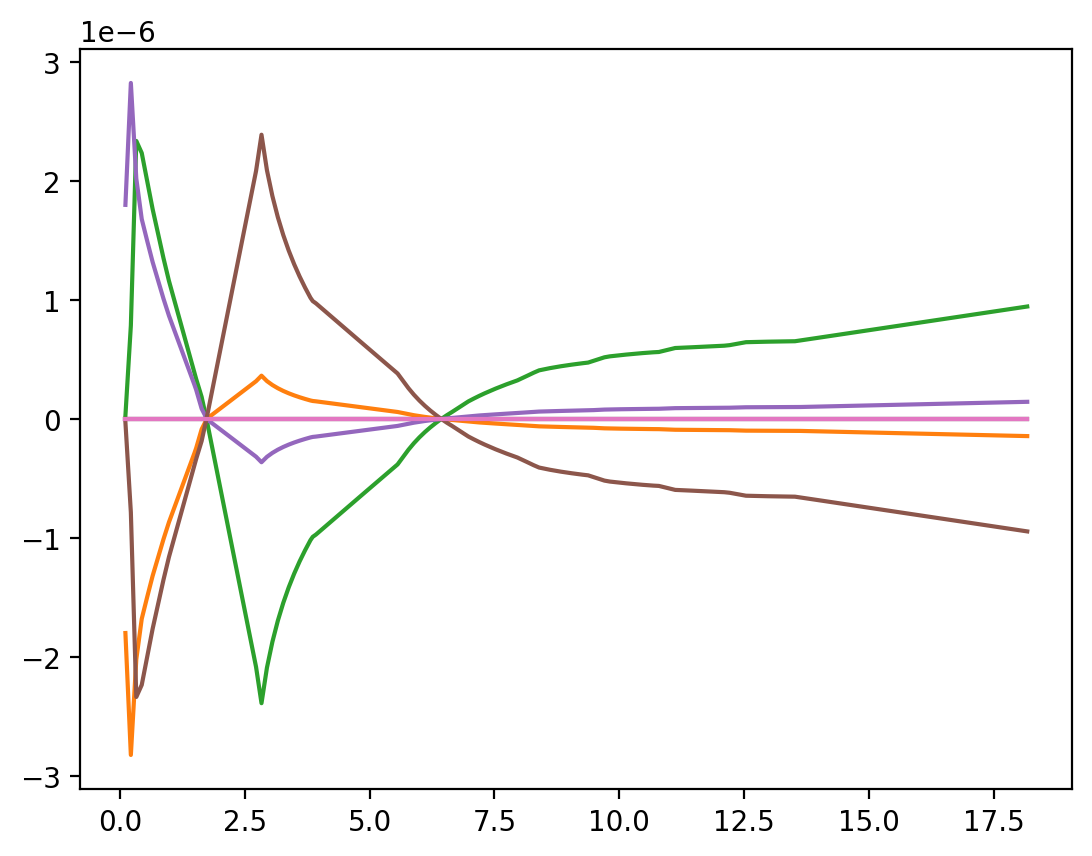

In [20]:
# Traces can be made by gathering the coordinate arrays
plt.plot(
    [P.z for P in  A.particles],
    [P.x for P in  A.particles]
)
plt.plot()

In [21]:
A.particles[-1]['mean_kinetic_energy']

99449380.84893514

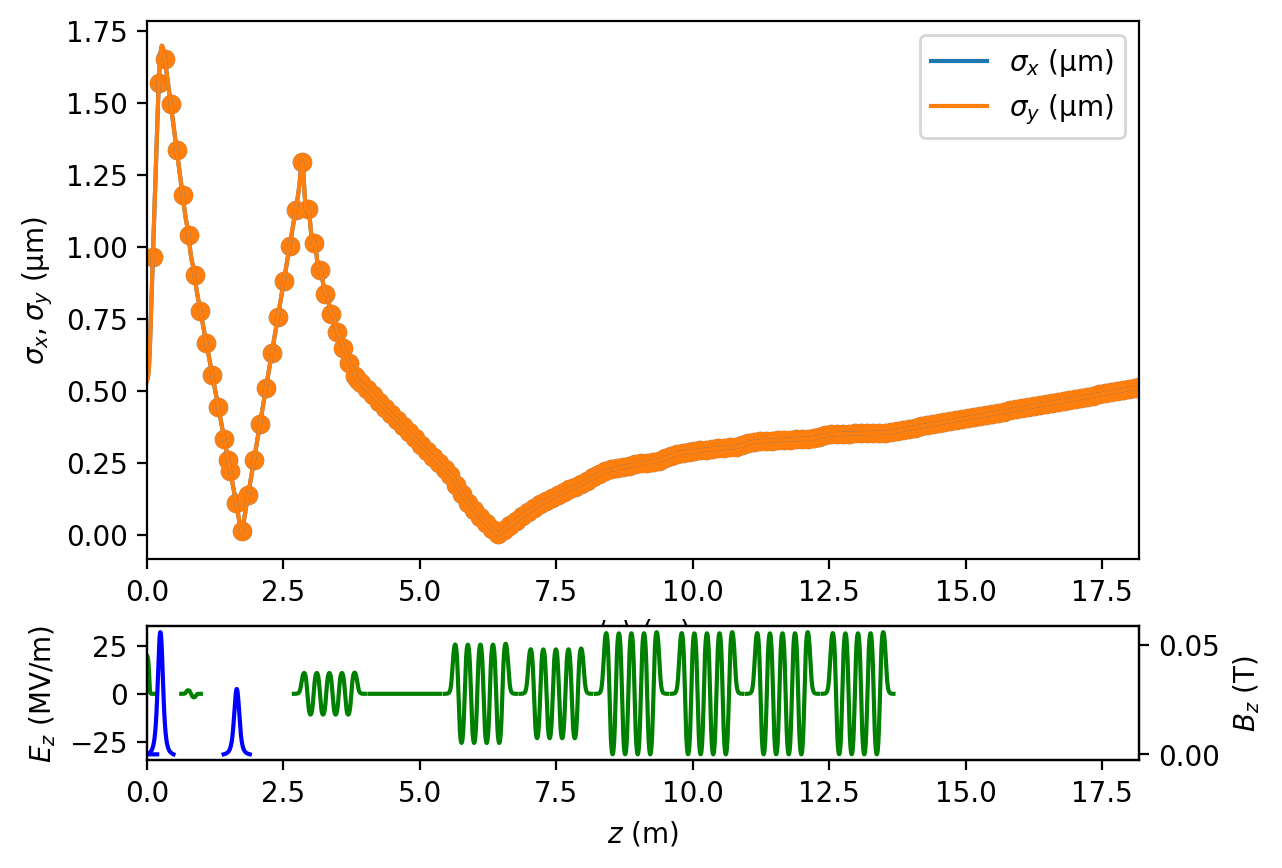

In [22]:
A.plot()

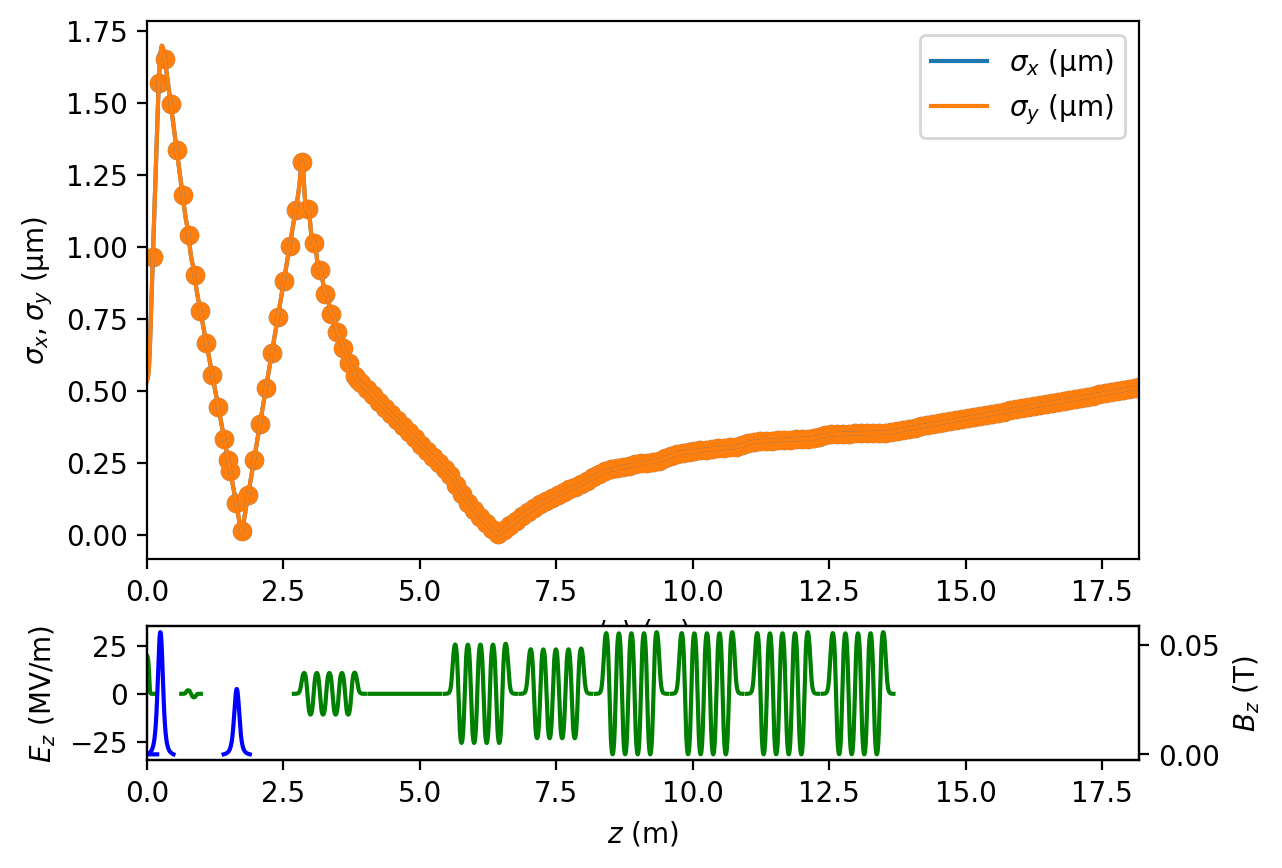

In [23]:
A.plot()

In [24]:
A.particles[-1].x

array([ 0.00000000e+00, -1.44134094e-07,  9.45497791e-07,  0.00000000e+00,
        1.44134094e-07, -9.45497791e-07,  0.00000000e+00])

In [25]:
A.output['run_info']

{'start_time': 1662657373.204101,
 'run_script': '/Users/chrisonian/Code/Astra/bin/Astra astra.in',
 'why_error': '',
 'run_time': 0.7523300647735596,
 'run_error': False}

## Tao

In [26]:
from pytao import Tao
from pytao.misc.markers import make_markers
from pmd_beamphysics import ParticleGroup
import pandas as pd
import numpy as np
import os

In [27]:
MODEL = '$LCLS_LATTICE/bmad/models/sc_inj/'

In [28]:
LATFILE = 'lat.bmad'
MARKERFILE = 'markers.bmad'

slist = np.linspace(0, ZSTOP, 150)
make_markers(slist, filename=MARKERFILE);

LAT = f"""
call, file = $LCLS_LATTICE/bmad/models/sc_inj/sc_inj.lat.bmad
call, file = {MARKERFILE}
"""

with open(LATFILE, 'w') as f:
    f.write(LAT)

In [29]:
%%time
tao = Tao(f'-init {MODEL}/tao.init -noplot -slice BEGINNING:ENDL0B -lat {LATFILE}')
tao.cmd(f'set beam_init position_file = {P0FILE}')
tao.cmd('beamon')

CPU times: user 51.5 s, sys: 647 ms, total: 52.2 s
Wall time: 52.2 s


[]

In [30]:
ix = tao.lat_list('marker::*', 'ele.ix_ele')
df = pd.DataFrame(map(tao.bunch_params, ix))

PG1 = [ ParticleGroup(data=tao.bunch_data(i)) for i in ix]
len(PG1)

169

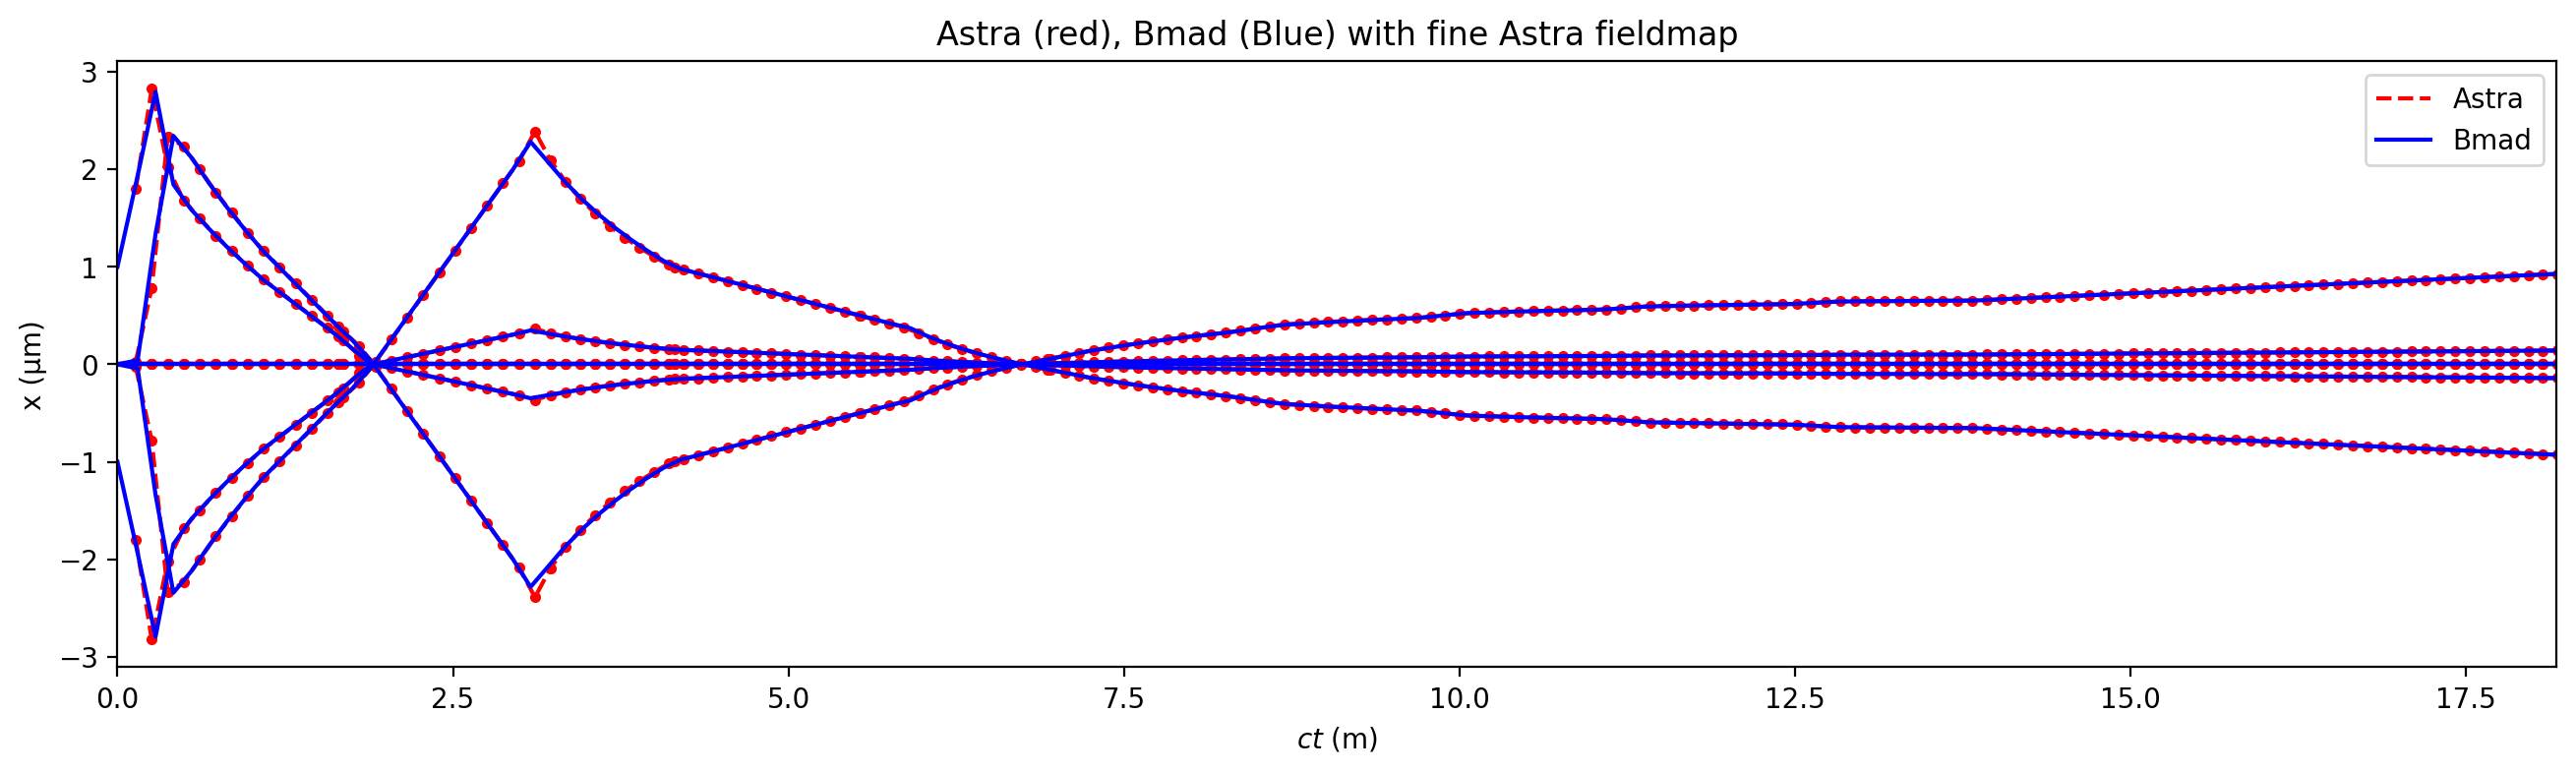

In [31]:
# Traces can be made by gathering the coordinate arrays

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16,4))

ykey = 'x'
yscale = 1e6
yunit = r'µm'
ylabel = f'{ykey} ({yunit})'

ax.plot(
    [P.t*299792458 for P in  A.particles],
    [P[ykey]*yscale for P in  A.particles], color='red', linestyle='--', marker='.',
)

ax.plot(
    [P.t*299792458 for P in  PG1],
    [P[ykey]*yscale  for P in  PG1], color='blue', label='Bmad', # marker='.',
)

ax.set_xlim(0, ZSTOP)
#ax.set_ylim(0.5e6, 2e6)

custom_lines = [Line2D([0], [0], color='red', linestyle='--'),
                Line2D([0], [0], color='blue')]
ax.legend(custom_lines, ['Astra', 'Bmad'])

ax.set_xlabel(f'$ct$ (m)')
ax.set_ylabel(ylabel)
plt.title('Astra (red), Bmad (Blue) with fine Astra fieldmap')
plt.savefig('sc_inj-Bmad-Astra-comparison.png', bbox_inches='tight', dpi=150)

In [32]:
PG1[150]['mean_t']*299792458

16.88675328033437

In [33]:
PG1[150]['mean_kinetic_energy']

99519973.50607476

In [34]:
A.particles[-1]['mean_kinetic_energy']

99449380.84893514

# Check fields (debugging)

(None,
 {'eleAnchorPt': 'center',
  'gridGeometry': 'cylindrical',
  'axisLabels': array(['r', 'theta', 'z'], dtype='<U5'),
  'gridLowerBound': array([0, 1, 0]),
  'gridOriginOffset': array([ 0.  ,  0.  , -0.65]),
  'gridSpacing': array([0.0005, 0.    , 0.0005]),
  'gridSize': array([ 207,    1, 2601]),
  'harmonic': 1,
  'fundamentalFrequency': 1300000000.0,
  'RFphase': 0,
  'fieldScale': 1.0})

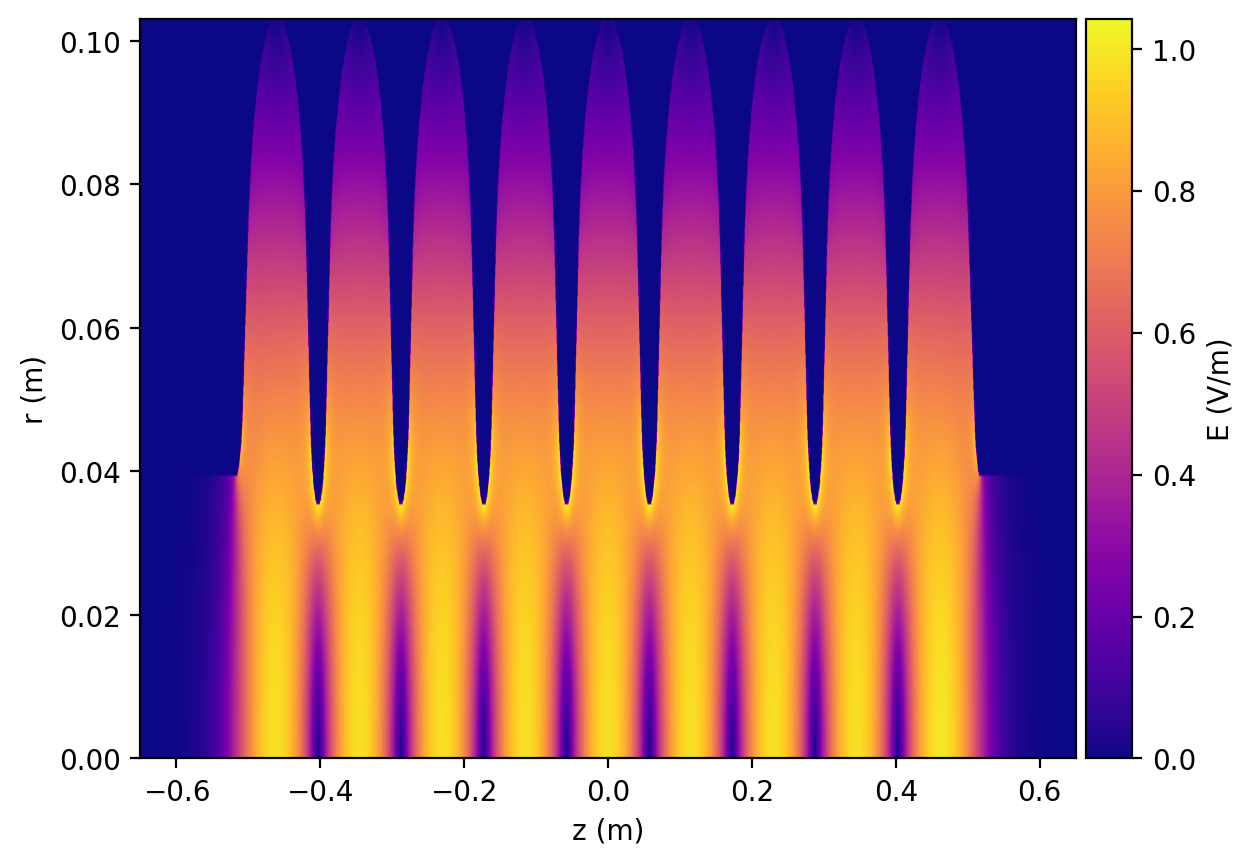

In [35]:
from pmd_beamphysics import FieldMesh
#FM = FieldMesh('$LCLS_LATTICE/bmad/fieldmaps/apex_gun/apex_gun_fieldmesh.h5')
FM = FieldMesh('$LCLS_LATTICE/bmad/fieldmaps/cavity9/cavity9_1300MHz_full.h5')
#FM = FieldMesh('$LCLS_LATTICE/bmad/fieldmaps/apex_buncher/apex_buncher_1300MHz_center.h5')
FM.plot(), FM.attrs

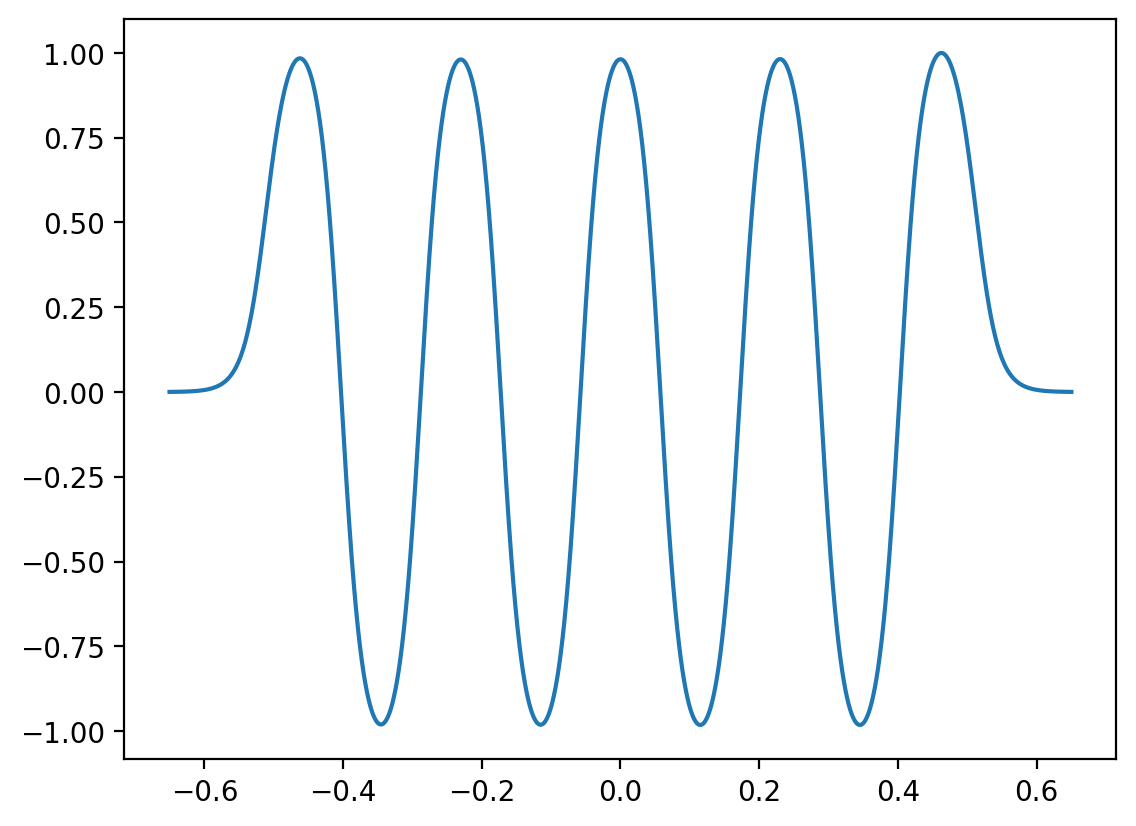

In [36]:
z0 =FM.coord_vec('z')
Ez0 = np.real(FM.Ez[0,0,:])
plt.plot(z0, Ez0)

In [37]:
Ez0.max(), Ez0.min()

(0.9999999999999999, -0.9818307531129551)

Text(0, 0.5, '$E_z$ (MV/m)')

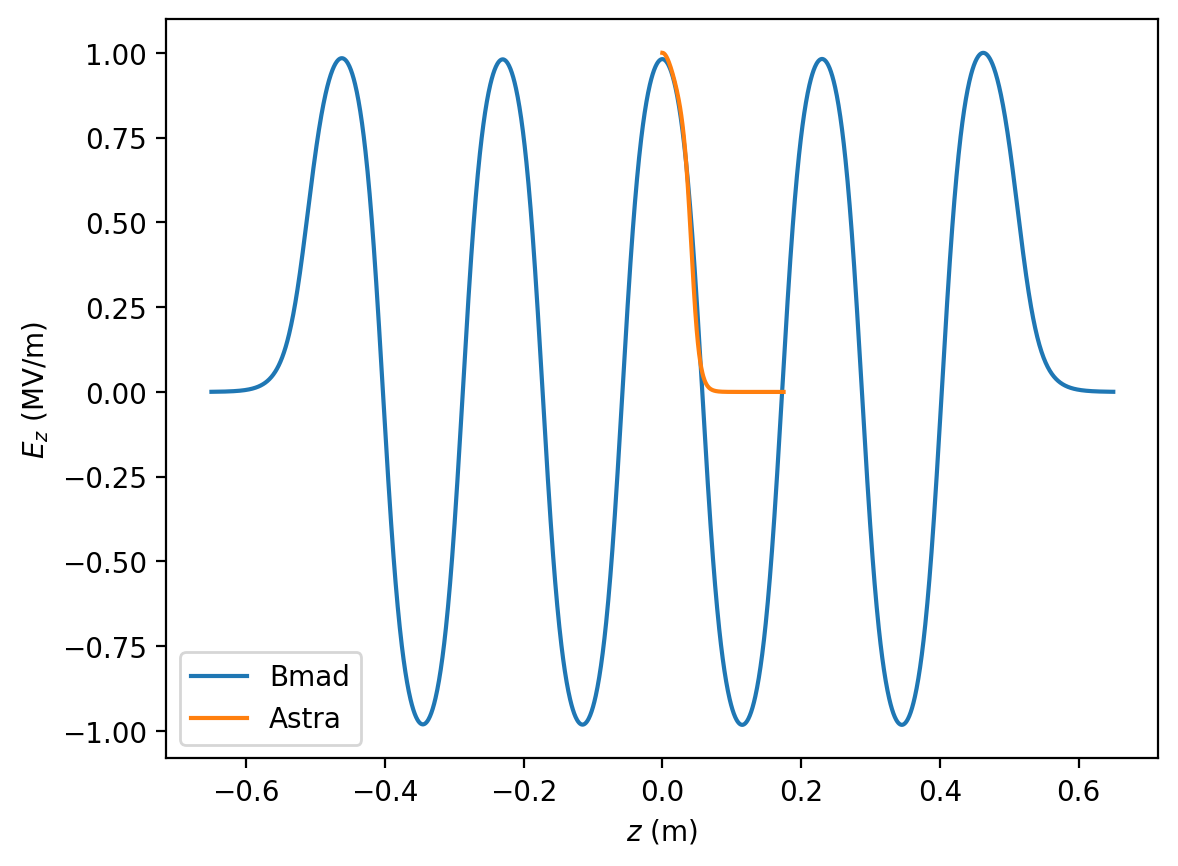

In [38]:

AEz0 = A.fieldmap['apex_gun_z_Ez.dat']['data']
plt.plot(z0, Ez0, label="Bmad")
#plt.plot(z0, Ez0[::-1], label="Bmad flipped")
plt.plot(AEz0[:,0], AEz0[:,1]/AEz0[:,1].max(), label='Astra')
plt.legend()
plt.xlabel(r'$z$ (m)')
plt.ylabel(r'$E_z$ (MV/m)')

In [39]:
AEz0.shape, Ez0.shape

((700, 2), (2601,))

In [40]:
np.trapz(Ez0, z0) * 20e6 / (np.trapz(AEz0[:,1]/AEz0[:,1].max(), AEz0[:,0]) * 20e6 )

2.886987291844848

In [41]:
from pmd_beamphysics.fields.analysis import autophase_field, accelerating_voltage_and_phase
from pmd_beamphysics.units import mec2

In [42]:
vacc, _ = accelerating_voltage_and_phase(z0, Ez0, frequency = 1.3e9)
vacc * 32e6

17186307.68473253

In [43]:
phase_deg1, pz1 = autophase_field(FM, pz0=100e6, scale=32e6)
energy1 = np.sqrt(pz1**2 + mec2**2) 
kenergy1 = energy1 - mec2
phase_deg1, pz1, kenergy1, energy1

(245.17647546613068,
 117186054.67712772,
 116676169.84726068,
 117187168.79726069)

In [44]:
# Python
kenergy1

116676169.84726068

In [45]:
# Bmad KE
1.2712357E+06 - mec2

760236.75

In [46]:
# Astra energy
A.particles[-1]['mean_energy']

99960379.79893515

In [47]:
PG1[-1]['mean_energy']

100030972.45607476

In [48]:
PG1[-1]['mean_energy']/A.particles[-1]['mean_energy']

1.0007062063717806

# Autoscaling helper

In [49]:
def ele_info(ele):
    dat = tao.ele_head(ele)
    dat.update(tao.ele_gen_attribs(ele))
    return dat

def ele_table(match="*"):
    ix_ele = tao.lat_list(match, "ele.ix_ele", flags="-no_slaves")
    dat = list(map(ele_info, ix_ele))
    df = pd.DataFrame(dat, index=ix_ele)
    df.L.fillna(0, inplace=True)
    df['s_center'] = df['s'] - df['L']/2
    df['s_beginning'] = df['s'] - df['L']
    return  df

df = ele_table().set_index('name')

In [50]:
s = df['PHI0_AUTOSCALE'].dropna()
lines = []
for name, value in s.items():
    lines.append(f"{name}[PHI0_AUTOSCALE] = {value}")
print('\n'.join(lines))

RFGUNB[PHI0_AUTOSCALE] = 0.226165735075198
BUN1B[PHI0_AUTOSCALE] = 0.0439852782944293
CAVL011[PHI0_AUTOSCALE] = 0.568732509822927
CAVL012[PHI0_AUTOSCALE] = 0.0
CAVL013[PHI0_AUTOSCALE] = 0.676827683851013
CAVL014[PHI0_AUTOSCALE] = 0.68043853471213
CAVL015[PHI0_AUTOSCALE] = 0.680737095023558
CAVL016[PHI0_AUTOSCALE] = 0.680974498176583
CAVL017[PHI0_AUTOSCALE] = 0.680937785299525
CAVL018[PHI0_AUTOSCALE] = 0.680975722180883
